### This notebook generates figure 1 of the Shahbazi et al. 2026 paper

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.scripts.script_plotting_utils as plu

#### import the .tsv files to plot

In [46]:
df_L2reg = pd.read_csv('../../tsv/L2reg_heatmap.tsv', sep='\t')
df_NNLS = pd.read_csv('../../tsv/NNLS_heatmap.tsv', sep='\t')
df_diff = pd.read_csv('../../tsv/Diff_heatmap.tsv', sep='\t')

ds_order = ["MDTB", "Language", "Social", "WMFS", "Demand", "Somatotopic", "Nishimoto", "IBC", "HCPur100"]

save_plots = False

#### ===========
####   PANEL A
#### ===========

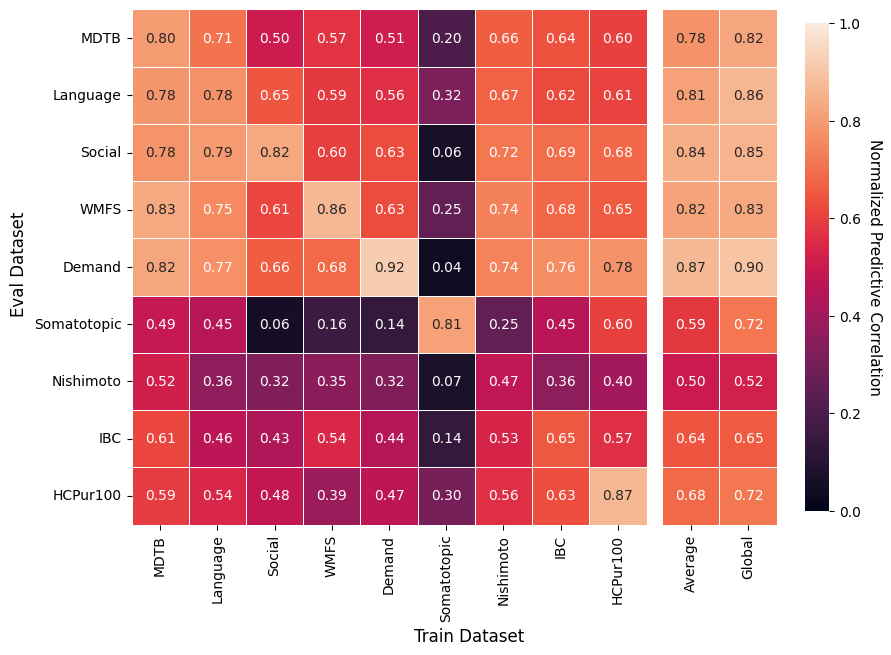

In [13]:
fig = plt.figure(figsize=(9, 7.2))
fig, ax1, ax2, cbar_ax = plu.plot_heatmap_annotate(df_L2reg, x_order=ds_order+["Average", "Global"], y_order=ds_order, fig=fig)
fig.supxlabel('Train Dataset', y=-0.03, fontsize=12)
fig.supylabel('Eval Dataset', x=-0.01, fontsize=12)
cbar_ax.set_label("Normalized Predictive Correlation", fontsize=11, rotation=270, labelpad=15)

if save_plots:
    fig.savefig(gl.fig_dir + "/fig01_a.pdf", bbox_inches="tight", dpi=300)

In [88]:
print(f"Same VS Average paired t-test results:")
print(f"{'Dataset':<15} {'t-statistic':<15} {'p-value':<15}")
print("-" * 45)

for ds in ds_order:
    df_average = df_L2reg[(df_L2reg['train_dataset'] == "Average") &
                          (df_L2reg['eval_dataset'] == ds)]["R_eval_adj"].reset_index(drop=True)
    df_same = df_L2reg[(df_L2reg['train_dataset'] == ds) &
                       (df_L2reg['eval_dataset'] == ds)]["R_eval_adj"].reset_index(drop=True)

    t_stat, p_val = stats.ttest_rel(df_same, df_average, nan_policy='omit', alternative='greater')

    print(f"{ds:<15} {t_stat:<15.3f} {p_val:<15.4f}")

Same VS Average paired t-test results:
Dataset         t-statistic     p-value        
---------------------------------------------
MDTB            2.551           0.0089         
Language        -2.352          0.9841         
Social          -0.883          0.8065         
WMFS            2.161           0.0236         
Demand          6.854           0.0000         
Somatotopic     4.846           0.0009         
Nishimoto       -0.919          0.7998         
IBC             0.218           0.4158         
HCPur100        9.532           0.0000         


In [87]:
print(f"Average VS Best paired t-test results:")
print(f"{'Dataset':<15} {'Best_ds':<15} {'t-statistic':<15} {'p-value':<15}")
print("-" * 60)

for ds in ds_order:
    df_average = df_L2reg[(df_L2reg['train_dataset'] == "Average") &
                          (df_L2reg['eval_dataset'] == ds)]["R_eval_adj"].reset_index(drop=True)
    # find best dataset
    best_ds = (
        df_L2reg[
            (df_L2reg['train_dataset'].isin(ds_order)) &
            (df_L2reg['train_dataset'] != ds) &
            (df_L2reg['eval_dataset'] == ds)
        ]
        .groupby('train_dataset')['R_eval_adj']
        .mean()
        .idxmax()
    )
    df_best = df_L2reg[(df_L2reg['train_dataset'] == best_ds) &
                       (df_L2reg['eval_dataset'] == ds)]["R_eval_adj"].reset_index(drop=True)

    t_stat, p_val = stats.ttest_rel(df_average, df_best, nan_policy='omit', alternative='greater')

    print(f"{ds:<15} {best_ds:<15} {t_stat:<15.3f} {p_val:<15.4f}")

Average VS Best paired t-test results:
Dataset         Best_ds         t-statistic     p-value        
------------------------------------------------------------
MDTB            Language        11.176          0.0000         
Language        MDTB            2.694           0.0080         
Social          Language        2.699           0.0067         
WMFS            MDTB            -1.826          0.9561         
Demand          MDTB            6.952           0.0000         
Somatotopic     HCPur100        -0.572          0.7075         
Nishimoto       MDTB            -1.124          0.8439         
IBC             MDTB            2.494           0.0149         
HCPur100        IBC             4.540           0.0000         


In [86]:
print(f"Global VS Average paired t-test results:")
print(f"{'Dataset':<15} {'t-statistic':<15} {'p-value':<15}")
print("-" * 45)

for ds in ds_order:
    df_average = df_L2reg[(df_L2reg['train_dataset'] == "Average") &
                          (df_L2reg['eval_dataset'] == ds)]["R_eval_adj"].reset_index(drop=True)
    df_global = df_L2reg[(df_L2reg['train_dataset'] == "Global") &
                       (df_L2reg['eval_dataset'] == ds)]["R_eval_adj"].reset_index(drop=True)

    t_stat, p_val = stats.ttest_rel(df_global, df_average, nan_policy='omit', alternative='greater')

    print(f"{ds:<15} {t_stat:<15.3f} {p_val:<15.4f}")

Global VS Average paired t-test results:
Dataset         t-statistic     p-value        
---------------------------------------------
MDTB            6.790           0.0000         
Language        5.697           0.0000         
Social          1.506           0.0735         
WMFS            1.363           0.0965         
Demand          7.090           0.0000         
Somatotopic     6.210           0.0002         
Nishimoto       2.556           0.0254         
IBC             0.718           0.2439         
HCPur100        4.676           0.0000         


#### ===========
####   PANEL B
#### ===========

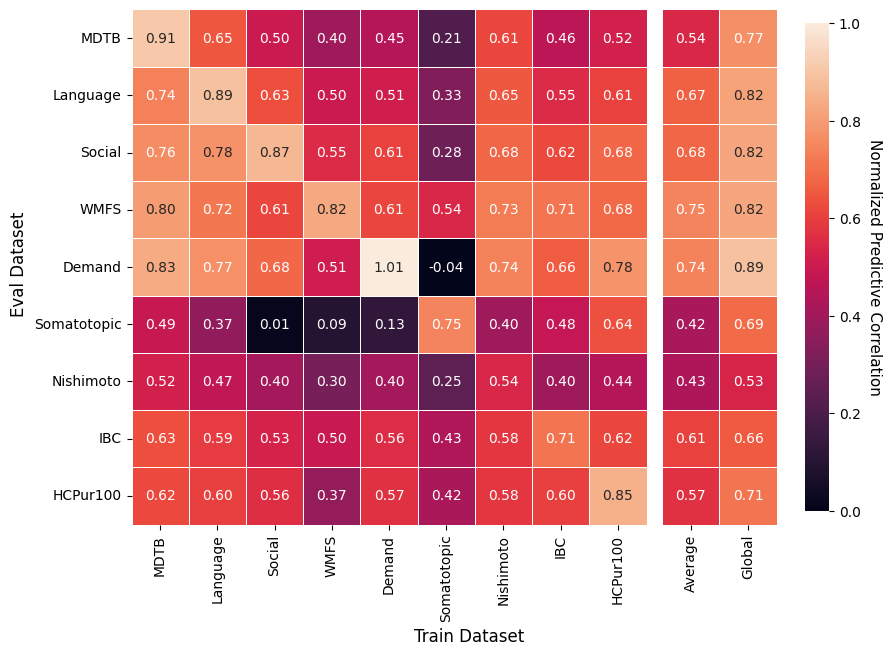

In [14]:
fig = plt.figure(figsize=(9, 7.2))
fig, ax1, ax2, cbar_ax = plu.plot_heatmap_annotate(df_NNLS, x_order=ds_order+["Average", "Global"], y_order=ds_order, fig=fig)
fig.supxlabel('Train Dataset', y=-0.03, fontsize=12)
fig.supylabel('Eval Dataset', x=-0.01, fontsize=12)
cbar_ax.set_label("Normalized Predictive Correlation", fontsize=11, rotation=270, labelpad=15)

if save_plots:
    fig.savefig(gl.fig_dir + "/fig01_b.pdf", bbox_inches="tight", dpi=300)

In [89]:
print(f"Same VS Average paired t-test results:")
print(f"{'Dataset':<15} {'t-statistic':<15} {'p-value':<15}")
print("-" * 45)

for ds in ds_order:
    df_average = df_NNLS[(df_NNLS['train_dataset'] == "Average") &
                          (df_NNLS['eval_dataset'] == ds)]["R_eval_adj"].reset_index(drop=True)
    df_same = df_NNLS[(df_NNLS['train_dataset'] == ds) &
                       (df_NNLS['eval_dataset'] == ds)]["R_eval_adj"].reset_index(drop=True)

    t_stat, p_val = stats.ttest_rel(df_same, df_average, nan_policy='omit', alternative='greater')

    print(f"{ds:<15} {t_stat:<15.3f} {p_val:<15.4f}")

Same VS Average paired t-test results:
Dataset         t-statistic     p-value        
---------------------------------------------
MDTB            16.482          0.0000         
Language        9.464           0.0000         
Social          5.126           0.0000         
WMFS            5.448           0.0000         
Demand          21.742          0.0000         
Somatotopic     7.511           0.0001         
Nishimoto       4.616           0.0029         
IBC             7.338           0.0000         
HCPur100        13.983          0.0000         


In [91]:
print(f"Best VS Average paired t-test results:")
print(f"{'Dataset':<15} {'Best_ds':<15} {'t-statistic':<15} {'p-value':<15}")
print("-" * 60)

for ds in ds_order:
    df_average = df_NNLS[(df_NNLS['train_dataset'] == "Average") &
                          (df_NNLS['eval_dataset'] == ds)]["R_eval_adj"].reset_index(drop=True)
    # find best dataset
    best_ds = (
        df_NNLS[
            (df_NNLS['train_dataset'].isin(ds_order)) &
            (df_NNLS['train_dataset'] != ds) &
            (df_NNLS['eval_dataset'] == ds)
        ]
        .groupby('train_dataset')['R_eval_adj']
        .mean()
        .idxmax()
    )
    df_best = df_NNLS[(df_NNLS['train_dataset'] == best_ds) &
                       (df_NNLS['eval_dataset'] == ds)]["R_eval_adj"].reset_index(drop=True)

    t_stat, p_val = stats.ttest_rel(df_best, df_average, nan_policy='omit', alternative='greater')

    print(f"{ds:<15} {best_ds:<15} {t_stat:<15.3f} {p_val:<15.4f}")

Best VS Average paired t-test results:
Dataset         Best_ds         t-statistic     p-value        
------------------------------------------------------------
MDTB            Language        10.284          0.0000         
Language        MDTB            3.200           0.0028         
Social          Language        6.314           0.0000         
WMFS            MDTB            7.219           0.0000         
Demand          MDTB            9.246           0.0000         
Somatotopic     HCPur100        6.289           0.0002         
Nishimoto       MDTB            5.914           0.0010         
IBC             MDTB            2.634           0.0116         
HCPur100        MDTB            6.272           0.0000         


In [92]:
print(f"Global VS Average paired t-test results:")
print(f"{'Dataset':<15} {'t-statistic':<15} {'p-value':<15}")
print("-" * 45)

for ds in ds_order:
    df_average = df_NNLS[(df_NNLS['train_dataset'] == "Average") &
                          (df_NNLS['eval_dataset'] == ds)]["R_eval_adj"].reset_index(drop=True)
    df_global = df_NNLS[(df_NNLS['train_dataset'] == "Global") &
                       (df_NNLS['eval_dataset'] == ds)]["R_eval_adj"].reset_index(drop=True)

    t_stat, p_val = stats.ttest_rel(df_global, df_average, nan_policy='omit', alternative='greater')

    print(f"{ds:<15} {t_stat:<15.3f} {p_val:<15.4f}")

Global VS Average paired t-test results:
Dataset         t-statistic     p-value        
---------------------------------------------
MDTB            13.052          0.0000         
Language        6.943           0.0000         
Social          6.569           0.0000         
WMFS            5.297           0.0000         
Demand          16.116          0.0000         
Somatotopic     6.460           0.0002         
Nishimoto       6.040           0.0009         
IBC             4.599           0.0004         
HCPur100        11.448          0.0000         


#### ===========
####   PANEL C
#### ===========

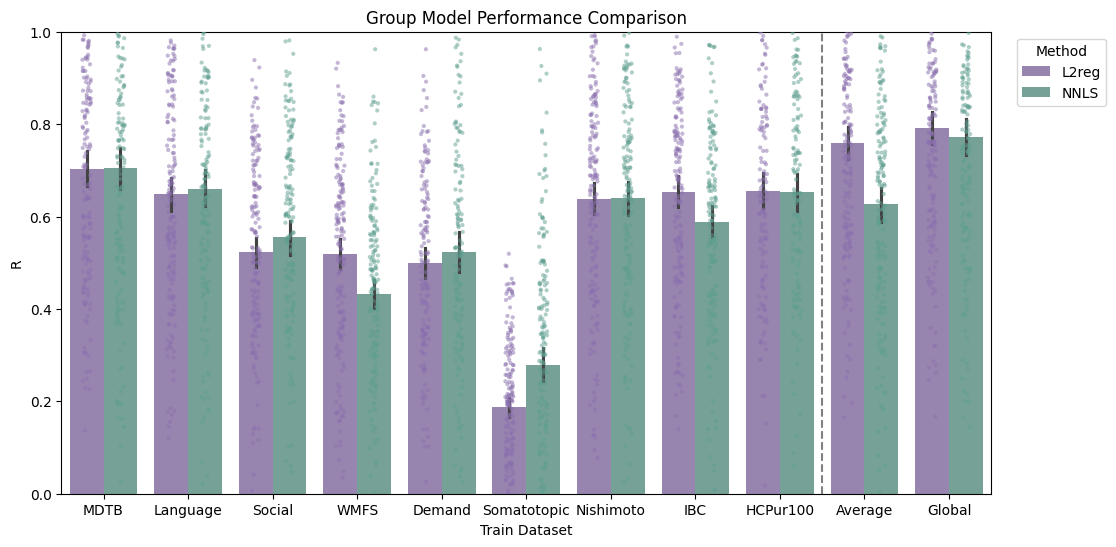

In [15]:
df_all = pd.concat([df_L2reg[df_L2reg.train_dataset != df_L2reg.eval_dataset],
                    df_NNLS[df_NNLS.train_dataset != df_NNLS.eval_dataset]]).reset_index(drop=True)

plt.figure(figsize=(12,6))
plu.plot_barplot_with_error(df_all)
plt.ylim(0,1)
plt.title('Group Model Performance Comparison')
plt.ylabel('R')
plt.xlabel('Train Dataset')
plt.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.axvline(x=8.5, color='gray', linestyle='--')

if save_plots:
    plt.savefig(gl.fig_dir + "/fig01_c_bar.pdf", bbox_inches="tight", dpi=300)

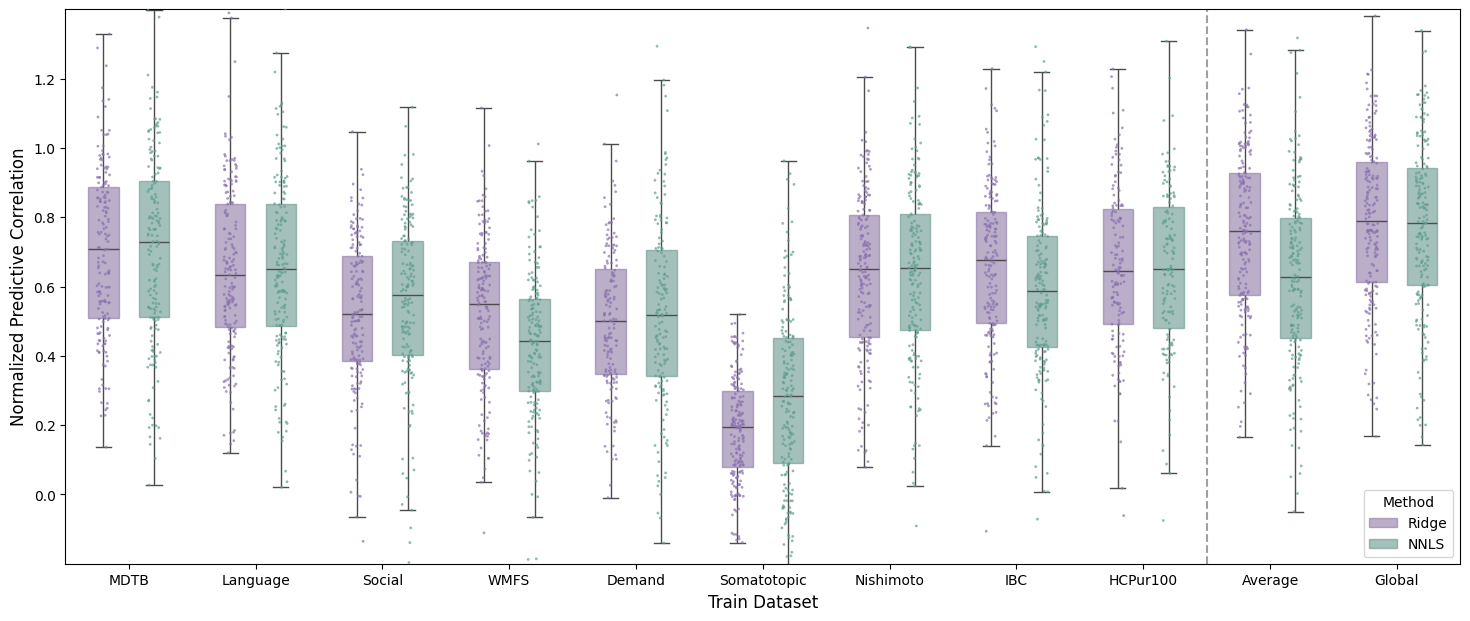

In [44]:
df_all = pd.concat([df_L2reg[df_L2reg.train_dataset != df_L2reg.eval_dataset],
                    df_NNLS[df_NNLS.train_dataset != df_NNLS.eval_dataset]]).reset_index(drop=True)

fig = plt.figure(figsize=(18,7.2))
ax = plu.plot_boxplot_strip(df_all, alpha=0.7)
ax.set_ylabel("Normalized Predictive Correlation", fontsize=12)
ax.set_xlabel("Train Dataset", fontsize=12)
ax.set_yticks(np.arange(0, 1.21, 0.2))
ax.set_ylim([-0.2, 1.4])

handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=["Ridge", "NNLS"],
    title="Method"
)
ax.axvline(x=8.5, color='gray', linestyle='--', alpha=0.75);

if save_plots:
    fig.savefig(gl.fig_dir + "/fig01_c.pdf", bbox_inches="tight", dpi=300)

In [107]:
print(f"Ridge VS NNLS paired t-test results:")
print(f"{'Dataset':<15} {'t-statistic':<15} {'p-value':<15} {'Winner':<15}")
print("-" * 60)

df_all = pd.concat([df_L2reg, df_NNLS], axis=0).reset_index(drop=True)

# pivot_df = df_all.pivot(index=["train_dataset", "eval_subj"], 
#                       columns="method", values="R_eval_adj")

for ds in ds_order:
    df_sub_L2 = df_L2reg[(df_L2reg['train_dataset'] == ds) &
                         (df_L2reg['eval_dataset'] != ds)]["R_eval_adj"].reset_index(drop=True)
    df_sub_NNLS = df_NNLS[(df_NNLS['train_dataset'] == ds) &
                         (df_NNLS['eval_dataset'] != ds)]["R_eval_adj"].reset_index(drop=True)

    t_stat, p_val = stats.ttest_rel(df_sub_L2, df_sub_NNLS, nan_policy='omit')

    winner = '----' if p_val > 0.05 else ('Ridge' if t_stat > 0 else 'NNLS')

    print(f"{ds:<15} {t_stat:<15.3f} {p_val:<15.9f} {winner}")

print("-" * 60)

for ds in ["Average", "Global"]:
    df_sub_L2 = df_L2reg[df_L2reg['train_dataset'] == ds]["R_eval_adj"].reset_index(drop=True)
    df_sub_NNLS = df_NNLS[df_NNLS['train_dataset'] == ds]["R_eval_adj"].reset_index(drop=True)

    t_stat, p_val = stats.ttest_rel(df_sub_L2, df_sub_NNLS, nan_policy='omit')

    winner = '----' if p_val > 0.05 else ('Ridge' if t_stat > 0 else 'NNLS')

    print(f"{ds:<15} {t_stat:<15.3f} {p_val:<15.9f} {winner}")


Ridge VS NNLS paired t-test results:
Dataset         t-statistic     p-value         Winner         
------------------------------------------------------------
MDTB            -0.312          0.755144995     ----
Language        -0.952          0.342453418     ----
Social          -4.505          0.000012332     NNLS
WMFS            10.392          0.000000000     Ridge
Demand          -1.533          0.127434356     ----
Somatotopic     -6.165          0.000000004     NNLS
Nishimoto       -0.014          0.989023536     ----
IBC             5.788           0.000000031     Ridge
HCPur100        0.215           0.829824461     ----
------------------------------------------------------------
Average         13.864          0.000000000     Ridge
Global          2.709           0.007356529     Ridge


#### ===========
####   PANEL D
#### ===========

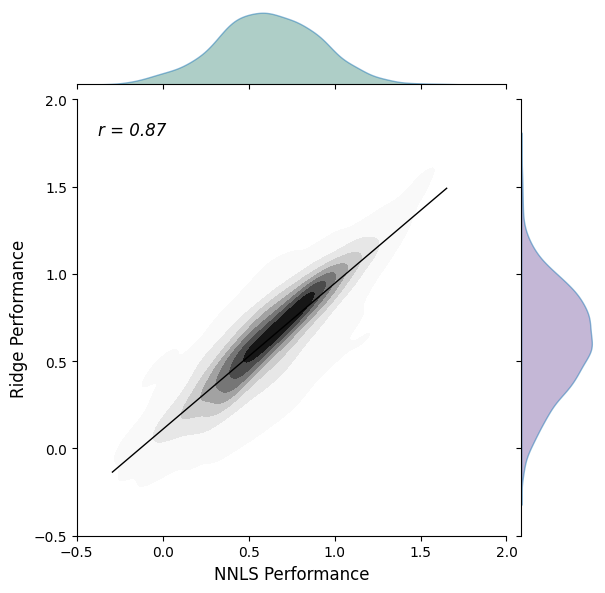

In [45]:
x = df_NNLS['R_eval_adj']
y = df_L2reg['R_eval_adj']

g = sns.JointGrid(x=x, y=y, height=6)

# KDE contour plot in the center
g.plot_joint(sns.kdeplot, fill=True, cmap="Greys", thresh=0.02, levels=8);

# Get colors
colors = plu.get_color_palette()

# Marginal distributions
g.plot_marginals(sns.kdeplot, fill=True)
g.ax_marg_x.collections[0].set_facecolor(colors['NNLS'])
g.ax_marg_x.collections[0].set_alpha(0.5)
g.ax_marg_y.collections[0].set_facecolor(colors['L2reg'])
g.ax_marg_y.collections[0].set_alpha(0.5)

# Add regression line manually
m, b, r, p, se = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
g.ax_joint.plot(x_line, m * x_line + b, color="black", lw=1)

# Add correlation annotation
g.ax_joint.text(0.05, 0.95, f"r = {r:.2f}", transform=g.ax_joint.transAxes,
                fontsize=12, fontstyle="italic", va="top")

g.set_axis_labels("NNLS Performance", "Ridge Performance", fontsize=12)
g.ax_joint.set_xlim(-0.5, 2);
g.ax_joint.set_ylim(-0.5, 2);

if save_plots:
    plt.savefig(gl.fig_dir + "/fig01_d.pdf", bbox_inches="tight", dpi=300)